In [32]:
import os
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

In [33]:
BASE_DIR = Path().resolve()

GENERATION_DIR = BASE_DIR.parent / "generated_biographies"
RESOURCES_DIR  = BASE_DIR / "resources"
OUTPUT_DIR     = BASE_DIR / "outputs"

GENDER_DIR        = RESOURCES_DIR / "gender"
DISABILITIES_DIR  = RESOURCES_DIR / "disabilities"
NAME_ENTITIES_DIR = RESOURCES_DIR / "name_entities"


# Gender

### Automatic gender attribution to biographies

In [34]:
from resources.gender.gender_detection import apply_gender_detection

In [35]:
df_gender = apply_gender_detection(GENERATION_DIR)
df_gender.to_csv(OUTPUT_DIR / "gender_markers_bios.csv")
df_gender

,file_name,bio,genre_auto,Detailed_counter,Detailed_markers
0,llama_v2_short_withdis_2.txt,Marie Dupont naît en 1955 dans un petit villag...,Fem,"{'Fem': 4, 'Masc': 1}","[déterminée, élève, brillante, professeur, sex..."
1,llama_v1_short_withdis_0.txt,Léa Dubois naît en 1965 dans un petit village ...,Fem,{'Fem': 3},"[artiste, reconnue, sexe féminin]"
2,mistral_v2_short_nodis_0.txt,"Un individu fictif, Jean-Pierre Dupont, est né...",Masc,{'Masc': 1},[ingénieur]
3,llama_v1_long_nodis_1.txt,Léonard Dumont naît le 12 février 1923 dans un...,Masc,{'Masc': 1},[sexe masculin]
4,qwen_v1_long_nodis_2.txt,"Élise Moreau est née le 12 mai 1985 à Lyon, da...",Fem,{'Fem': 3},"[née, illustratrice, sexe féminin]"
...,...,...,...,...,...
103,mistral_v1_long_withdis_2.txt,Une histoire extraordinaire se déroule autour ...,Fem,"{'Fem': 7, 'Masc': 2}","[artiste, née, Diagnostiquée, perdu, admise, i..."
104,llama_v1_short_nodis_2.txt,Née le 12 février 1920 dans un petit village d...,Fem,{'Fem': 2},"[Née, couturière]"
105,mistral_v1_long_nodis_0.txt,Cette biographie raconte la vie de Jeanne Dubo...,Fem,"{'Fem': 5, 'Masc': 5}","[artiste, franco-américaine, née, sculpteur, p..."
106,qwen_v2_short_nodis_1.txt,Élise Moreau est née le 12 octobre 1985 à Lyon...,Fem,{'Fem': 3},"[née, sexe féminin, décédée]"


In [36]:
# Check automatic gender attribution to human annotation
from resources.helper_functions import get_cohen_kappa
score = get_cohen_kappa(csv_path=GENDER_DIR / "gender_markers_bios_annotated.csv",
                column1="genre_auto",
                column2="annotation")
print(f"Cohen's Kappa score between machine and human annotation: {score:.2f}")

Cohen's Kappa score between machine and human annotation: 1.00


In [37]:
from resources.helper_functions import get_versions
df_gender = get_versions(df_gender)

In [38]:
def gender_summary(df, label):
    counts = df["genre_auto"].value_counts()
    pourcentage = df["genre_auto"].value_counts(normalize=True) * 100
    summary = pd.DataFrame({"n": counts, "%": pourcentage.round(2)})
    summary.index.name = "Gender"
    print(f"  {label}  (n={len(df)})")
    print(summary.to_string())

nodis   = df_gender[df_gender["version"] == "nodis"]
withdis = df_gender[df_gender["version"] == "withdis"]

gender_summary(nodis,   "no disability")
gender_summary(withdis, "with disability")
gender_summary(df_gender,  "total")

  no disability  (n=54)
         n     %
Gender          
Masc    27  50.0
Fem     27  50.0
  with disability  (n=54)
         n      %
Gender           
Fem     39  72.22
Masc    15  27.78
  total  (n=108)
         n      %
Gender           
Fem     66  61.11
Masc    42  38.89


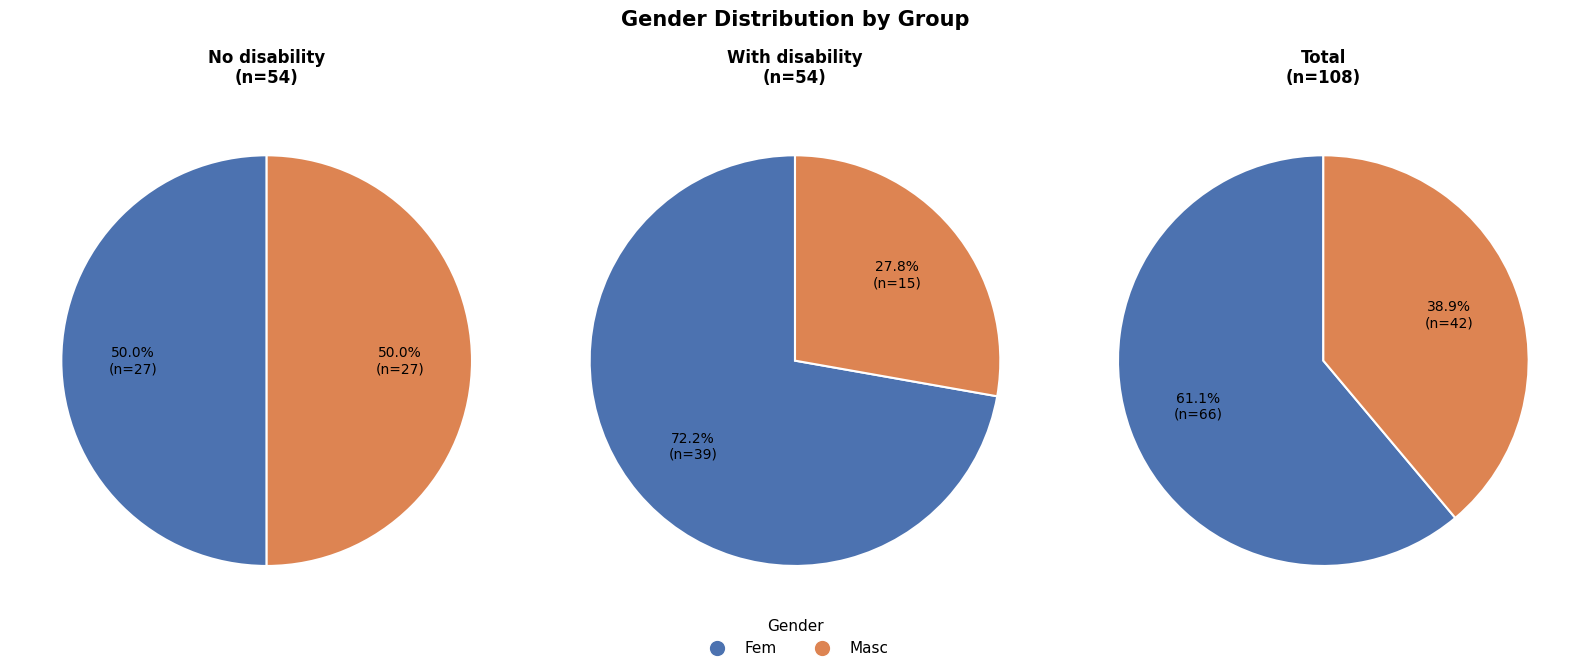

In [39]:
def plot_gender_pies(df_out):
    nodis   = df_out[df_out["version"] == "nodis"]
    withdis = df_out[df_out["version"] == "withdis"]

    datasets = {
        f"No disability\n(n={len(nodis)})":    nodis,
        f"With disability\n(n={len(withdis)})": withdis,
        f"Total\n(n={len(df_out)})":             df_out
    }

    colors = ["#4C72B0", "#DD8452"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle("Gender Distribution by Group", fontsize=15, fontweight="bold", y=1.05)

    all_genders = df_out["genre_auto"].value_counts().index.tolist()

    for ax, (title, df) in zip(axes, datasets.items()):
        counts = df["genre_auto"].value_counts().reindex(all_genders, fill_value=0)

        ax.pie(
            counts,
            labels=None,
            colors=colors[:len(counts)],
            autopct=lambda p: f"{p:.1f}%\n(n={int(round(p * counts.sum() / 100))})",
            startangle=90,
            pctdistance=0.65,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5}
        )
        ax.set_title(title, fontsize=12, fontweight="bold", pad=15)

    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=colors[i], markersize=12)
        for i in range(len(all_genders))
    ]
    fig.legend(
        legend_handles,
        all_genders,
        title="Gender",
        loc="lower center",
        ncol=len(all_genders),
        fontsize=11,
        title_fontsize=11,
        frameon=False,
        bbox_to_anchor=(0.5, -0.05)
    )

    plt.tight_layout()
    plt.show()

plot_gender_pies(df_gender)

### Check markers depending on genders

In [40]:
df_annotated = pd.read_csv(GENDER_DIR / "gender_markers_bios_annotated.csv")

In [41]:
def parse_markers(val):
    if not isinstance(val, str):
        return []
    val = val.strip().strip('[]')
    if not val:
        return []
    return [x.strip() for x in val.split(',')]

df_annotated['parsed_markers'] = df_annotated['Detailed_markers'].apply(parse_markers)

In [42]:
fem_markers = Counter(m for markers in df_annotated[df_annotated['genre_auto'] == 'Fem']['parsed_markers'] for m in markers)
masc_markers = Counter(m for markers in df_annotated[df_annotated['genre_auto'] == 'Masc']['parsed_markers'] for m in markers)

In [43]:
fem_markers

Counter({'née': 44,
         "'sexe féminin'": 41,
         'décédée': 24,
         'artiste': 14,
         'femme': 11,
         'illustratrice': 10,
         'reconnue': 6,
         'conseillère': 6,
         'française': 5,
         'institutrice': 4,
         'nommée': 4,
         'connue': 4,
         'déterminée': 3,
         'professeur': 3,
         'écrivaine': 3,
         'Née': 3,
         'rédactrice': 3,
         'diagnostiquée': 3,
         'enfant': 2,
         'exceptionnelle': 2,
         'assistante': 2,
         'enseignante': 2,
         'peintre': 2,
         'contemporaine': 2,
         'invitée': 2,
         'élève': 1,
         'brillante': 1,
         'engagée': 1,
         'curieuse': 1,
         'conservatrice': 1,
         'récompensée': 1,
         'chanteuse': 1,
         'marquée': 1,
         'entourée': 1,
         'prodigieuse': 1,
         'handicapée': 1,
         'mathématicienne': 1,
         'mondiale': 1,
         'ingénieur': 1,
         'direct

In [44]:
masc_markers

Counter({'né': 19,
         "'sexe masculin'": 18,
         'homme': 7,
         'décédé': 7,
         'nommé': 5,
         'professeur': 5,
         'Né': 5,
         'français': 5,
         'ingénieur': 4,
         'écrivain': 4,
         'inventeur': 3,
         'connu': 3,
         'physicien': 3,
         'mort': 3,
         'scientifique': 3,
         'peintre': 3,
         'exceptionnel': 2,
         'Diagnostiqué': 2,
         'garçon': 2,
         'néerlandais': 2,
         'interprète': 1,
         'historien': 1,
         'Écrivain': 1,
         'Chevalier': 1,
         'découragé': 1,
         'pianiste': 1,
         'doué': 1,
         'Connu': 1,
         'conseiller': 1,
         'frère': 1,
         'élève': 1,
         'mathématicien': 1,
         'musicien': 1,
         'réputé': 1,
         'invité': 1,
         'enfant': 1,
         'intelligent': 1,
         'connue': 1,
         'diagnostiqué': 1,
         'assistant': 1,
         'canadien': 1,
         '-': 1,
 

# Disabilities

In [45]:
from resources.disabilities.disabilities_detection import PATTERN_FR, REVERSE_LOOKUP_FR, collect_hits, get_categories

In [46]:
rows = []
for file in (f for f in os.scandir(GENERATION_DIR) if f.name.endswith('.txt')):
    with open(file.path, 'r', encoding='utf-8') as f:
        text = f.read()
        rows.append({"file_name": file.name, "disabilities": collect_hits(PATTERN_FR, text)})

df_dis = pd.DataFrame(rows)

In [47]:
df_dis["categories"] = df_dis["disabilities"].apply(lambda hits: get_categories(hits, REVERSE_LOOKUP_FR))

In [48]:
df_dis

,file_name,disabilities,categories
0,llama_v2_short_withdis_2.txt,"[malformation, mobilité, handicapés]","[autres handicaps ou maladies, handicaps moteu..."
1,llama_v1_short_withdis_0.txt,[],[]
2,mistral_v2_short_nodis_0.txt,[],[]
3,llama_v1_long_nodis_1.txt,[],[]
4,qwen_v1_long_nodis_2.txt,[],[]
...,...,...,...
103,mistral_v1_long_withdis_2.txt,[],[]
104,llama_v1_short_nodis_2.txt,[],[]
105,mistral_v1_long_nodis_0.txt,[],[]
106,qwen_v2_short_nodis_1.txt,[],[]


In [49]:
df_dis = get_versions(df_dis)

In [50]:
mentioned_dis = df_dis[df_dis.disabilities.astype(bool)]

In [51]:
mentioned_dis.version.value_counts()

version
withdis    47
nodis       8
Name: count, dtype: int64

In [52]:
print(mentioned_dis[mentioned_dis["version"] == "nodis"])
print(mentioned_dis[mentioned_dis["version"] == "withdis"])

                       file_name                 disabilities  \
13     llama_v1_long_nodis_2.txt                     [cancer]   
49  mistral_v1_short_nodis_2.txt                     [cancer]   
50   mistral_v3_long_nodis_2.txt            [crise, blessure]   
53     llama_v3_long_nodis_2.txt                    [suicide]   
59     llama_v3_long_nodis_1.txt        [dépression, suicide]   
60      qwen_v3_long_nodis_2.txt                 [adaptation]   
63    llama_v3_short_nodis_0.txt  [intervention chirurgicale]   
94   mistral_v1_long_nodis_2.txt                      [crise]   

                                           categories version  
13                   [maladies chroniques évolutives]   nodis  
49                   [maladies chroniques évolutives]   nodis  
50  [autres handicaps ou maladies, handicaps moteurs]   nodis  
53            [handicap psychique et handicap mental]   nodis  
59            [handicap psychique et handicap mental]   nodis  
60                            

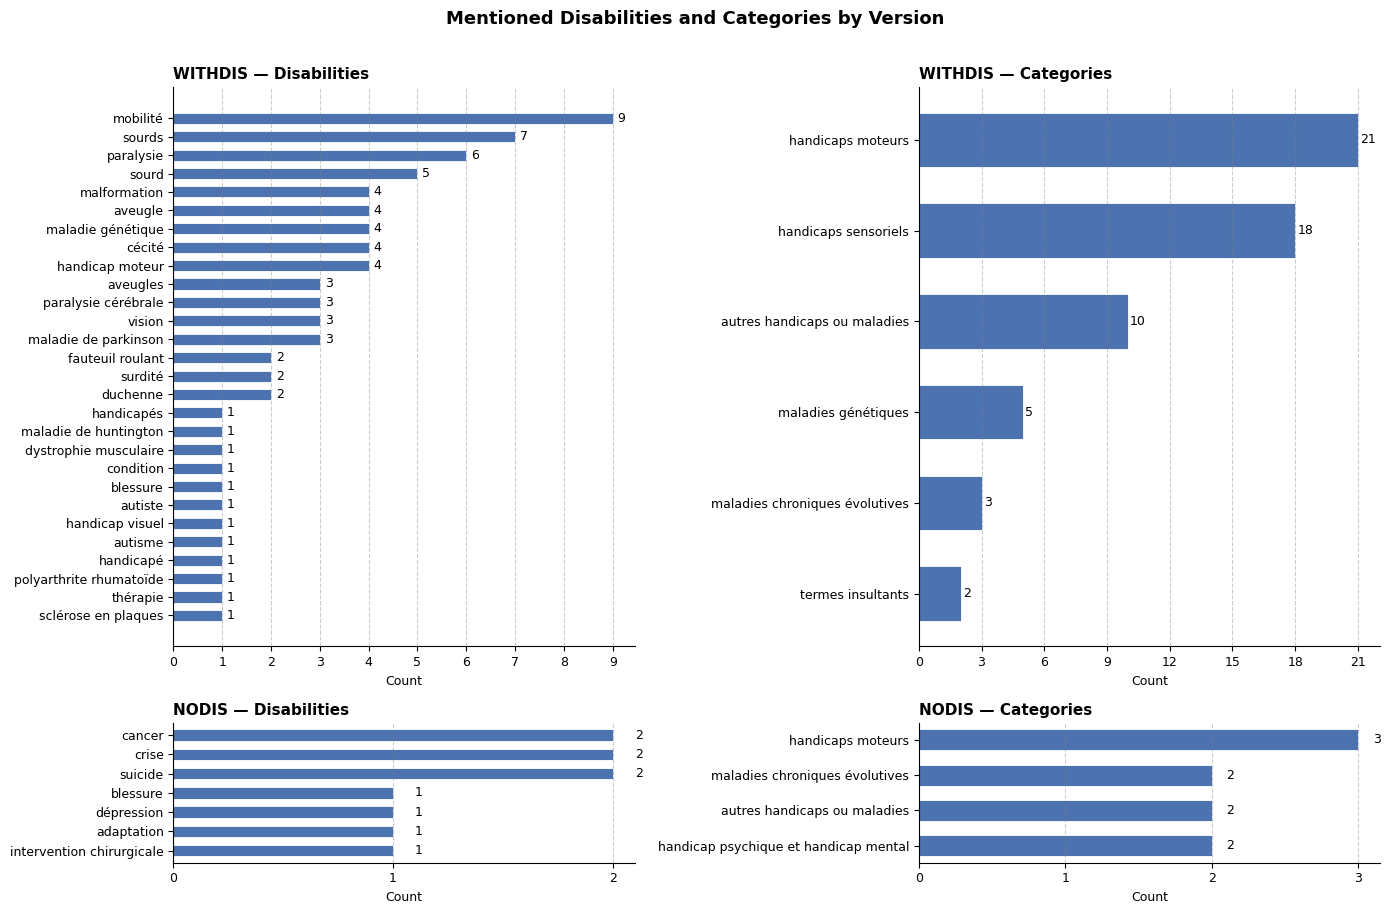

In [53]:
from resources.helper_functions import plot_version_summary

plot_version_summary(
    mentioned_dis,
    columns=["disabilities", "categories"],
    title="Mentioned Disabilities and Categories by Version",
    fig_width=14
)

# _Malgré_ study

In [54]:
df = pd.read_csv(RESOURCES_DIR / 'biographies_parsed.csv')

df = df[df["upos"].notna()].copy()

df["token_id"] = df["token_id"].astype(int)
df["sentence_id"] = df["sentence_id"].astype(int)


In [55]:
lookup = dict(zip(
    zip(df["doc_id"], df["sentence_id"], df["token_id"]),
    df["token"]
))

sentence_lookup = dict(zip(
    zip(df["doc_id"], df["sentence_id"]),
    df["sentence"]
))

df["head_token"] = df.apply(
    lambda r: lookup.get((r["doc_id"], r["sentence_id"], r["head_token_id"])), axis=1
)

In [56]:
malgre_rows = df[df["token"] == "malgré"].copy()

malgre_rows["prev_sentence"] = malgre_rows.apply(
    lambda r: sentence_lookup.get((r["doc_id"], r["sentence_id"] - 1)) if r["head_token"] == "cela" else None,
    axis=1
)

malgre_rows["disability_hits"] = malgre_rows["prev_sentence"].apply(
    lambda s: collect_hits(PATTERN_FR, s) if pd.notna(s) else []
)

In [57]:
malgre_rows[malgre_rows["head_token"]=="cela"]

,doc_id,term_id,paragraph_id,sentence_id,sentence,token_id,token,lemma,upos,feats,head_token_id,dep_rel,misc,vrai_token_id,compte,lower_token,head_token,prev_sentence,disability_hits
1987,llama_v1_short_withdis_0,47,1,3,"Malgré cela, Léa ne se laisse pas démonter et ...",1,malgré,malgré,ADP,NaN,2.0,case,NaN,1988,True,malgré,cela,"À l'âge de 5 ans, elle est victime d'un accide...",[]
2123,llama_v1_short_withdis_1,31,1,3,"Malgré cela, Léa n'a jamais abandonné ses rêves.",1,malgré,malgré,ADP,NaN,2.0,case,NaN,2124,True,malgré,cela,Elle est née avec une malformation du cerveau ...,[malformation]
4532,llama_v2_short_withdis_2,33,1,3,"Malgré cela, Marie est une personne très déter...",1,malgré,malgré,ADP,NaN,2.0,case,NaN,4533,True,malgré,cela,Elle est née avec une malformation du bras gau...,"[malformation, mobilité]"
6336,llama_v3_short_withdis_0,51,1,3,"Malgré cela, Hélène Boucher a continué à peind...",1,malgré,malgré,ADP,NaN,2.0,case,NaN,6337,True,malgré,cela,Cette maladie génétique progressive est caract...,[maladie génétique]
8917,mistral_v1_short_withdis_2,31,1,3,"Malgré cela, elle développe un amour pour la m...",1,malgré,malgré,ADP,NaN,2.0,case,NaN,8918,True,malgré,cela,Elle est atteinte de surdité depuis sa naissance.,[surdité]
9612,mistral_v2_long_withdis_0,46,1,3,"Malgré cela, Jacques avait une esprit remarqua...",1,malgré,malgré,ADP,NaN,2.0,case,NaN,9613,True,malgré,cela,"Il était atteint d'une maladie génétique rare,...","[maladie génétique, duchenne]"
9898,mistral_v2_long_withdis_1,90,1,5,"Malgré cela, elle a continué à fréquenter l'éc...",1,malgré,malgré,ADP,NaN,2.0,case,NaN,9899,True,malgré,cela,Émilie a acquis sa cécité à l'âge de trois ans...,[cécité]
11112,mistral_v2_short_withdis_2,29,1,2,"Malgré cela, il s'est engagé dans le domaine d...",1,malgré,malgré,ADP,NaN,2.0,case,NaN,11113,True,malgré,cela,"Alexandre, né en 1985 dans une petite ville fr...",[]
13201,mistral_v3_short_withdis_1,73,1,3,"Malgré cela, il a continué sa carrière académi...",1,malgré,malgré,ADP,NaN,2.0,case,NaN,13202,True,malgré,cela,"Né le 8 janvier 1942 à Londres, en Angleterre,...",[paralysie]
14098,qwen_v1_long_withdis_1,46,1,3,"Malgré cela, elle a su se battre pour sa liber...",1,malgré,malgré,ADP,NaN,2.0,case,NaN,14099,True,malgré,cela,"Dès son plus jeune âge, elle a été confrontée ...","[handicap moteur, paralysie]"


# NER

In [58]:
from resources.name_entities.name_entities_detection import get_ner

In [59]:
df_ner = get_ner(GENERATION_DIR)

In [60]:
df_ner

,file,names,organisations,locations
0,llama_v1_long_nodis_0.txt,"[Sophie, Sophie Dupont]",[École des Beaux - Arts de Paris],"[France, New - York, Paris]"
1,llama_v1_long_nodis_1.txt,"[Léonard, Léonard Dumont]",[gauche],[Paris]
2,llama_v1_long_nodis_2.txt,"[Élodie, Élodie Lefebvre]",[université de Lyon],[Lyon]
3,llama_v1_long_withdis_0.txt,"[Marie, Marie Dupont]",[],"[France, Lyon, Musée d ' art moderne de Lyon]"
4,llama_v1_long_withdis_1.txt,"[Duchenne, Léa, Léa Dupont]",[université de Lyon],"[France, Lyon]"
...,...,...,...,...
103,qwen_v3_short_nodis_1.txt,"[Élise, Élise Moreau]",[],"[Lyon, Paris]"
104,qwen_v3_short_nodis_2.txt,"[Louis Pasteur, Pasteur]",[],"[France, Sanary - sur - Mer, l ' Étang - Saint..."
105,qwen_v3_short_withdis_0.txt,"[Élise, Élise Martin]",[],"[France, Lyon, Paris]"
106,qwen_v3_short_withdis_1.txt,"[Élise, Élise Moreau]",[],"[France, Lyon]"


In [61]:
for i, row in df_ner.iterrows():
    if "nodis" in row["file"]:
        df_ner.at[i, "version"] = "nodis"
    else: df_ner.at[i, "version"] = "withdis"

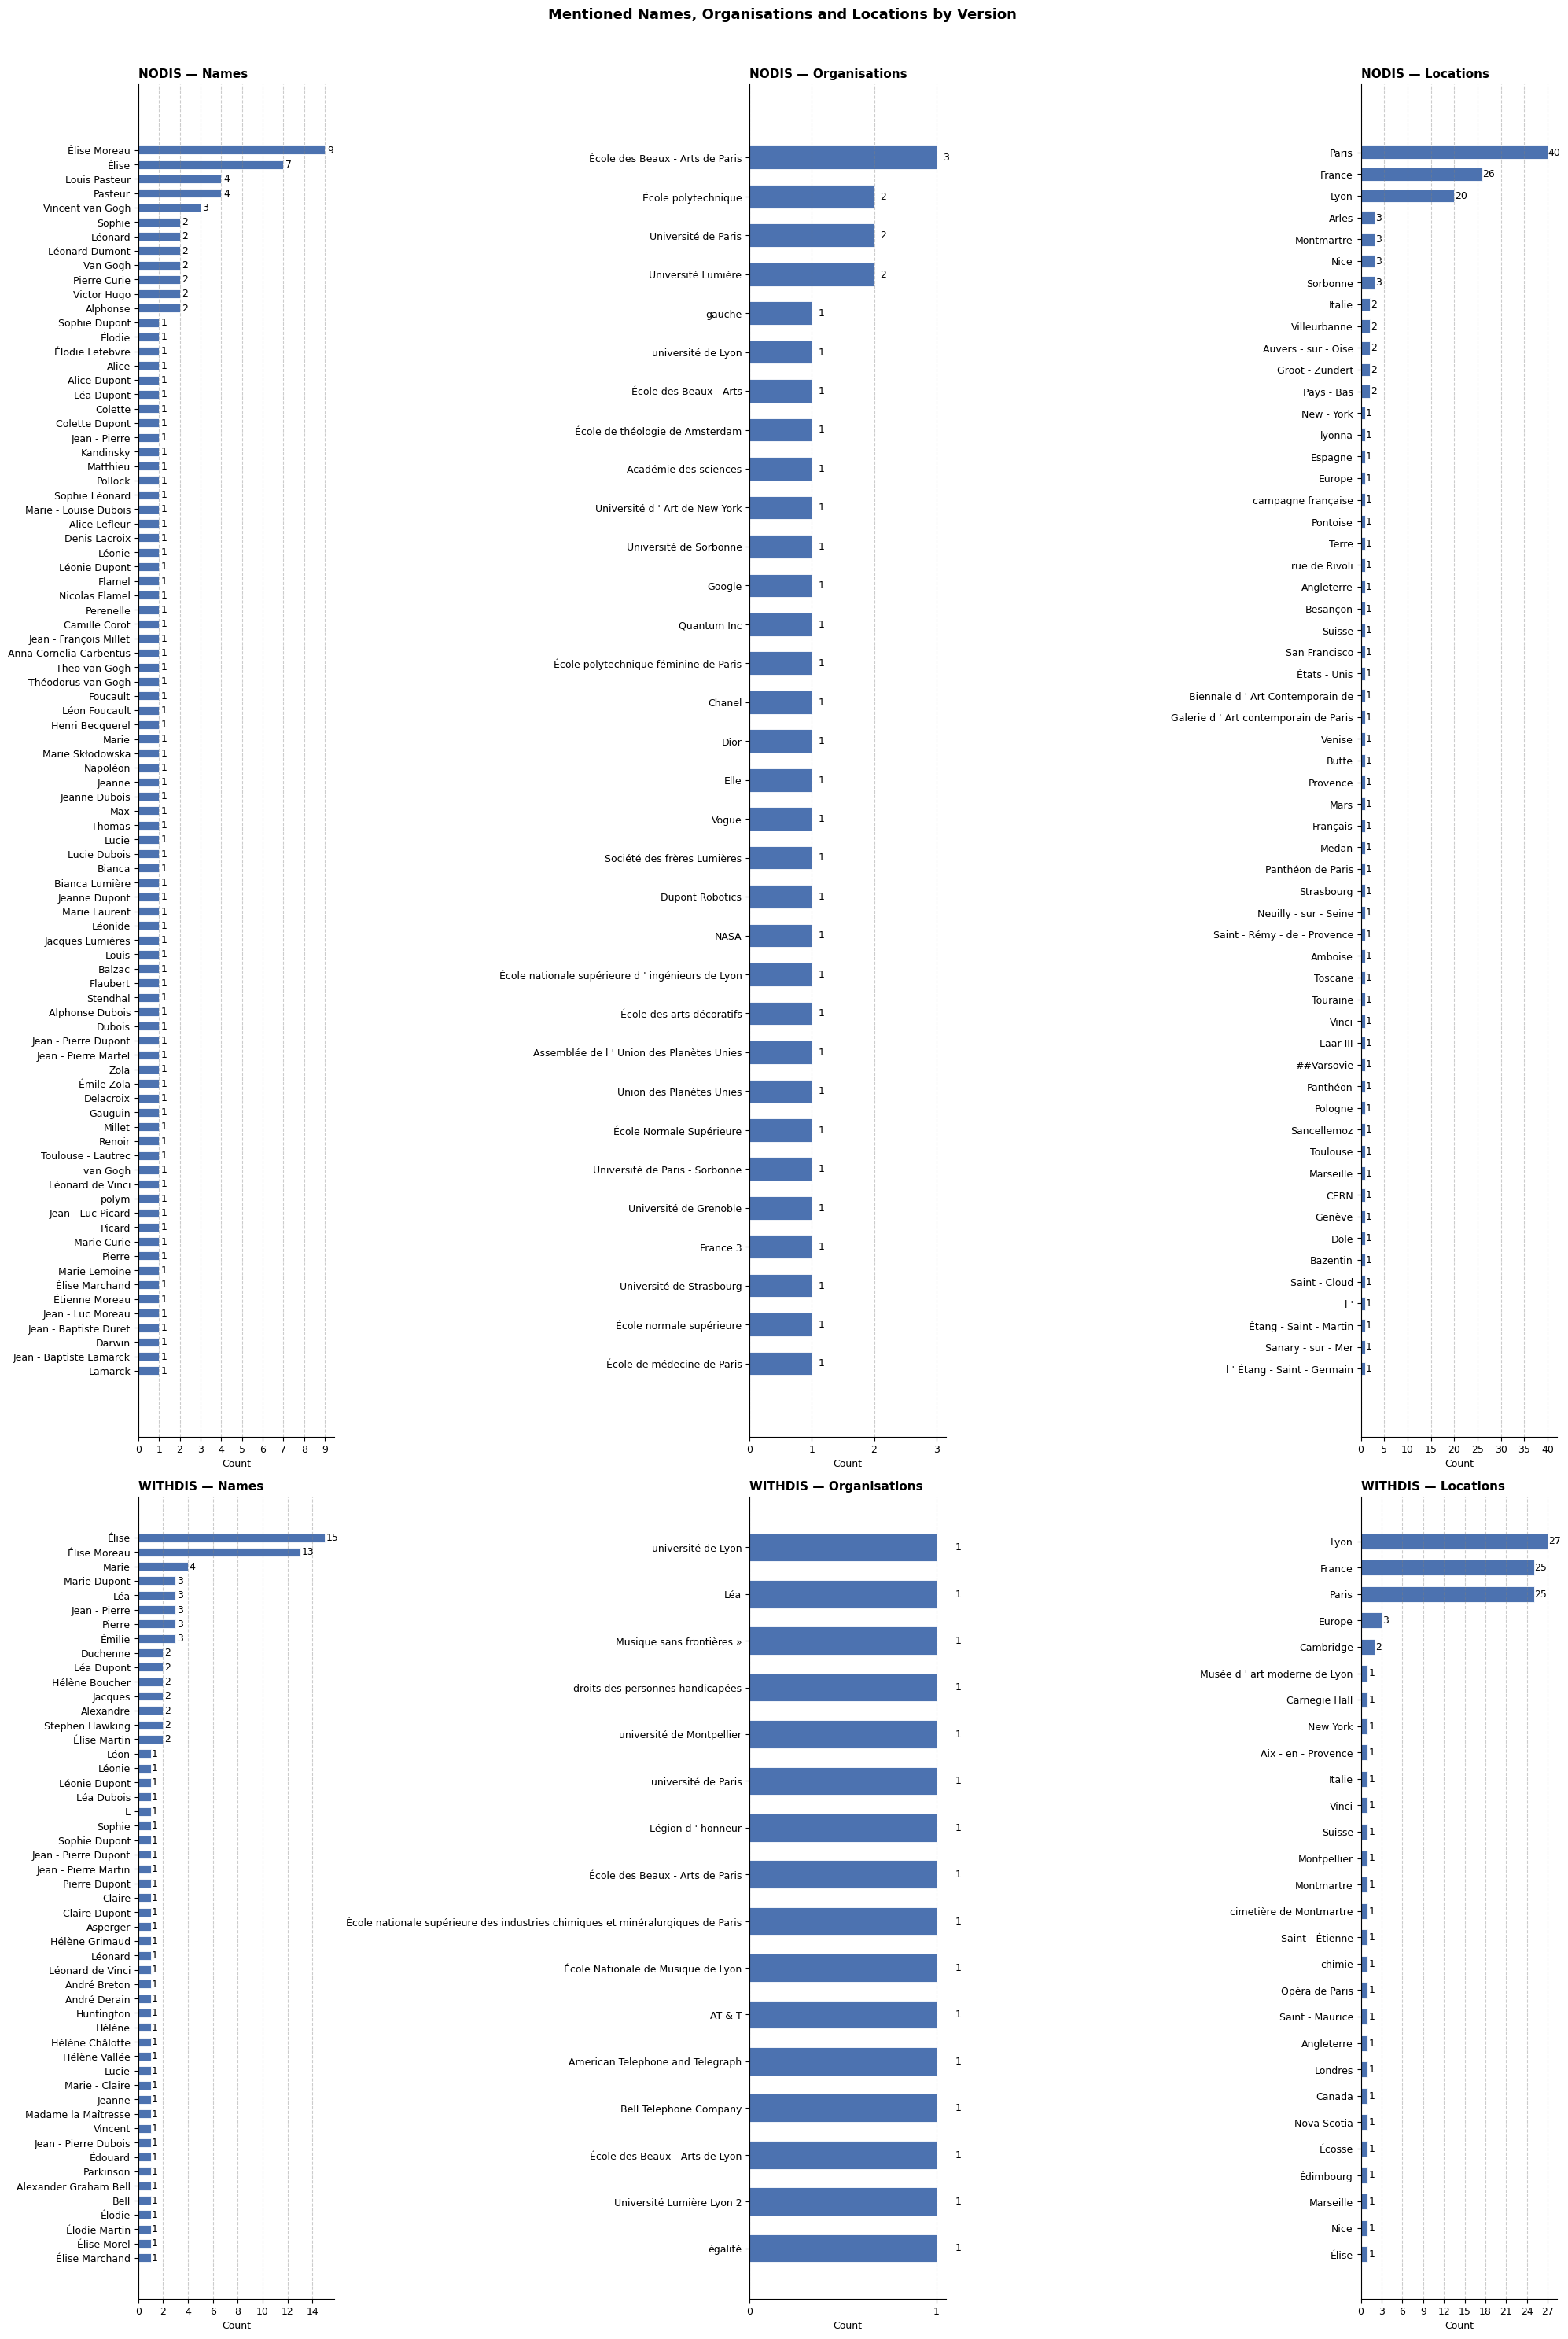

In [62]:
plot_version_summary(
    df_ner,
    columns=["names", "organisations", "locations"],
    title="Mentioned Names, Organisations and Locations by Version",
    fig_width=20
)